## Pytorch Workflow

In [1]:
what_we_are_covering={1:"data(prepare and load)",
                      2:"build model",
                      3:"fitting the model to data",
                      4:"making predictions and evaluating a model",
                      5:"saving and loading a model",
                      6:"putting it all together"}
what_we_are_covering                      

{1: 'data(prepare and load)',
 2: 'build model',
 3: 'fitting the model to data',
 4: 'making predictions and evaluating a model',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn # building blocks for neural networks
import matplotlib.pyplot as plt

# check pytorch version
print(torch.__version__)

2.5.1+cu121


### 1. Data (preparing and loading)
Data can be almost anything in machine learning

Machine learning is agme of two parts:
1. Get data into a numerical representations
2. Build a model to learn patterns in that representations

To showcase this lets create some known data using linear regression formula
We will use a linear regression formula to make a straight line known as parameters


In [3]:
#create knwon parameters
weight=0.7
bias=0.3

#Create a linear model
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias

X[:10],y[:10], len(X),len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

### Splitting data in training and testing

In [4]:
#create test and train data
train_split=int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Visualizing the data which sometimes is most important

In [5]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10,7))
    
    #plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    
    #plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    
    if predictions is not None:
        #plot the predictions in red
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
        
    plt.legend(prop={"size":14});

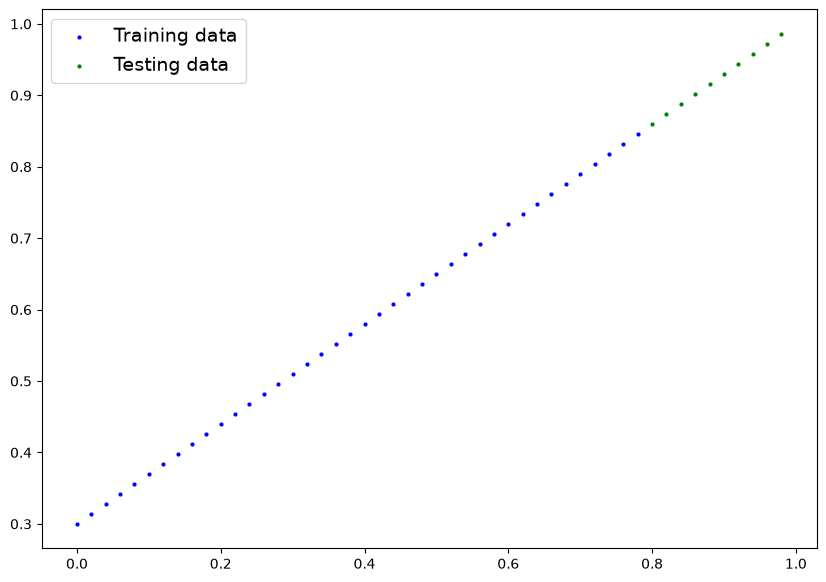

In [6]:
plot_predictions()

## 2. Building our first pytorch model

What our model does:
* Start with random values(weight and bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values(the weight and bias values we used to create the data)

How does it do so?
1. Gradient Descent 
2. Backrpropogation

In [48]:
#create a linear regression model
class LinearRegressionModel(nn.Module): # almost all models in PyTorch inherit from nn.Module
    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.randn(1,requires_grad=True,  # can this parameter be updated during training? yes, requires_grad=True means it will be updated during training
                                              dtype=torch.float))
        self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        
    def forward(self,x:torch.Tensor)->torch.Tensor: # x is input data and the function returns output data
        return self.weights*x+self.bias

### Pytorch model building essentials
* torch.nn- contains all of the buildings for computational graphs( a neural network can be considered a computational graph)
* torch.nn.parameter- what parameters should our model try and learn, often a Pytorch layer from torch.nn will set these for us
* torch.nn.Module- The base class for all neural networks modules , if you subclass it , you should overwrite forward()
* torch.optim- this is where the optimizers in pytorch live, they will help with gradient descent
* def forward- all nn.module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

### Now we have created a model , lets see whats inside
So we can check our model or whats inside our model using .parameters

In [67]:
# create a random seed for reproducibility
torch.manual_seed(42)

# create an instance of the model(this is a subclass of nn.Module)
model_0=LinearRegressionModel()

# check out parameters of the model
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [68]:
# list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [51]:
weight, bias

(0.7, 0.3)

### Making predictions using torch.inference_mode()
To check our model predective power , lets see how will it predicts y_test based on x_test.
When we pass data through our model its going to run it through thr forward() method

In [52]:
y_preds=model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [53]:
# make redictions
with torch.inference_mode(): # inference mode is used to turn off gradients, which reduces memory usage and speeds up computations
    y_preds=model_0(X_test)
y_preds    

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [13]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

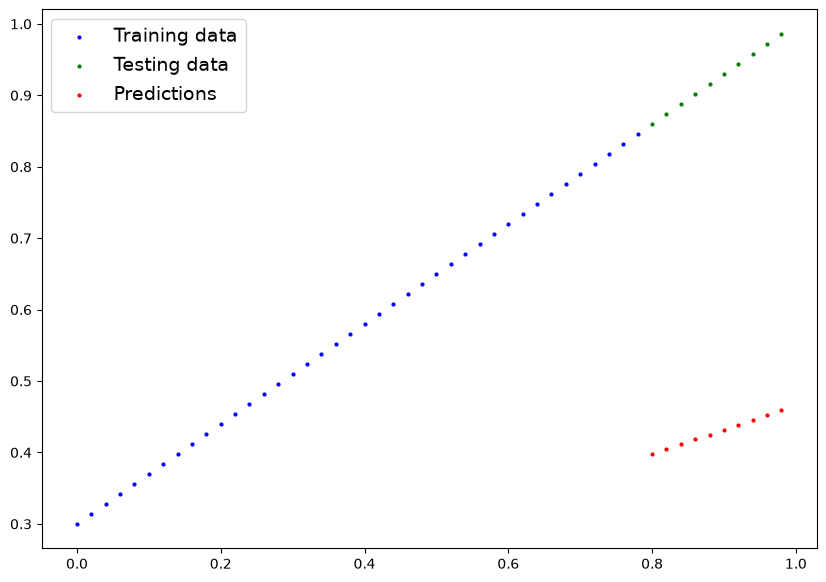

In [14]:
plot_predictions(predictions=y_preds)

## 3. Train model
the whole idea for training a model from some unknown parameters(these may be random) to some known parameters

Or in other words from a poor representation of the data to a better representation of the data

One way to measure how poor or how wrong your model prediction are is to use loss function

Note: loss func can also be called cosst func or criterion

Things we need to train:

**Loss func:** A func to measure how wrong your model's predictions are to the ideal outputs, lower is better.

**optimizers:** Takes into account the loss of a model and adjusts the models parameters(e.g weight & bias) to improvethe loss function.

And specifically for pytorch we need:
* A training loop
* A testing loop

In [15]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [16]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [69]:
#set up a loss function and optimizer
loss_fn=nn.L1Loss() # mean absolute error
optimizer=torch.optim.SGD(params=model_0.parameters(), lr=0.01)

### Building a tarining loop in ptorch

A couple of things we need in training loop:
0. Loop thru data
1. forward pass(this involves data moving thru model 'forward()' functions) to make predictions on data- also called forward propagation
2. calculate the loss 
3. Optimizer zero grad
4. Loss backward- move backwards thru the network to calculate the gradients of each of the paramters of our model with respect to the loss(backpropagation)
5. Optimizer step- use the optimizer to adjust our models parameters to try and improve the loss(gradient descent)

In [70]:
# a epoch is one loop through the data passed to the model in training
epochs=200

# Track diffrent values throughout training
epochs_count=[]
loss_values=[]
test_loss_values=[]

# 0. Loop through the data
for epoch in range(epochs):
    # set the model to training mode
    model_0.train() #training mode is used to turn on gradients, which allows the model to learn and update its parameters during training
    
    # 1. Forward pass
    y_pred=model_0(X_train)
    
    # 2. Calculate the loss
    loss=loss_fn(y_pred, y_train)
    print(f"Loss: {loss}")
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()
    
    # 4. Loss backward
    loss.backward()
    
    # 5. Optimizer step(perform gradient descent)
    optimizer.step() # by default, the optimizer will update all parameters in the model that have requires_grad=True
    
    ## Testing
    model_0.eval() # evaluation mode is used to turn off gradients, which reduces memory
    with torch.inference_mode(): # inference mode is used to turn off gradients, which reduces memory usage and speeds up computations
        test_pred=model_0(X_test)

        # calculate the loss
        test_loss=loss_fn(test_pred, y_test)
    if epoch%10==0:
        epochs_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch:{epoch} | Loss: {loss} | Test loss: {test_loss}")    

        #print out model state_dict
        print(model_0.state_dict())


    

Loss: 0.31288138031959534
Epoch:0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Loss: 0.3013603389263153
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713240146637
Epoch:10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])
Loss: 0.18615034222602844
Loss: 0.1746293306350708
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912236571312
Loss: 0.09681284427642822
Loss: 0.08908725529909134
Epoch:20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])
Loss: 0.08227583020925522
Loss: 0.07

In [75]:
import numpy as np
np.array(torch.tensor(loss_values).cpu().numpy()),test_loss_values

(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
        0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
        0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
        0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
       dtype=float32),
 [tensor(0.4811),
  tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.0806),
  tensor(0.0723),
  tensor(0.0647),
  tensor(0.0565),
  tensor(0.0482),
  tensor(0.0406),
  tensor(0.0323),
  tensor(0.0241),
  tensor(0.0165),
  tensor(0.0082),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050)])

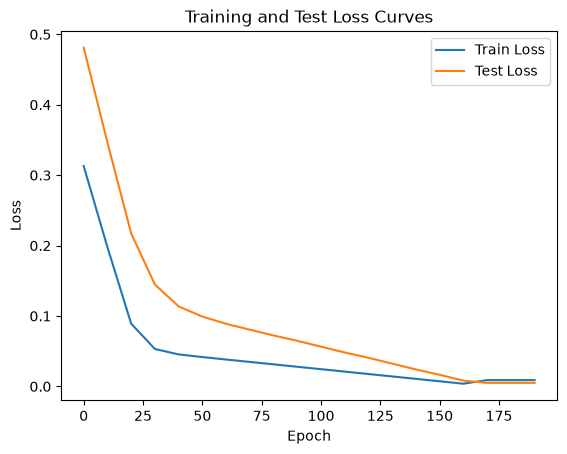

In [76]:
#plot loss curves
plt.plot(epochs_count, np.array(torch.tensor(loss_values).numpy()), label="Train Loss")
plt.plot(epochs_count, test_loss_values, label="Test Loss")
plt.title("Training and Test Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend();

In [71]:
with torch.inference_mode():
    y_preds=model_0(X_test)

In [72]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [63]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [73]:
weight, bias

(0.7, 0.3)

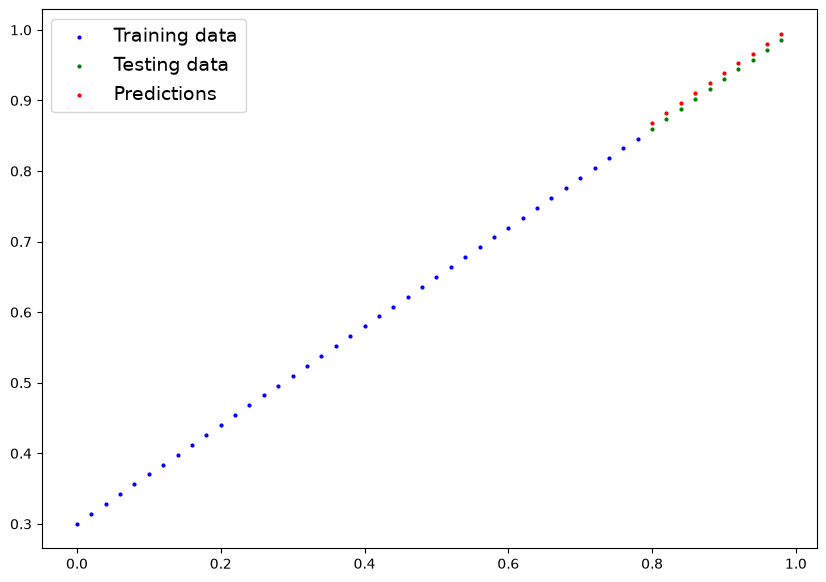

In [74]:
plot_predictions(predictions=y_preds);

## Saving a model in pytorch

There are three main methods you should know abt and loading model in Pytorch
1. 'torch.save()' - allows you save a pytorch object in python pickle format 
2. 'torch.load()'-allows you to load a saved pytorch object
3. 'torch.nn.Module'- this allows to load a models saved state dictionary

In [77]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [79]:
# saving our pytorch model
from pathlib import Path

#1. Create a directory to save the model
model_path=Path("models")
model_path.mkdir(parents=True, exist_ok=True)

#2. create a model save path
model_name="01_pytorch_workflow_model_0.pth"
model_save_path=model_path / model_name

model_save_path

#3. save the model state_dict
print(f"Saving model to: {model_save_path}")
torch.save(obj=model_0.state_dict(), f=model_save_path)

Saving model to: models\01_pytorch_workflow_model_0.pth


In [80]:
!ls -l models

total 4
-rw-r--r-- 1 richi 197609 1680 Jul 27 15:31 01_pytorch_workflow_model_0.pth


## Loading a pytorch model
Since we saved our model state_dict()rether the entire model, we will create a neq instance of our model class and load the saved state_dict() into that

In [81]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [82]:
# to load a model, we need to create a new instance of the model class and load the state_dict into it
loaded_model_0=LinearRegressionModel()

#load the state_dict
loaded_model_0.load_state_dict(torch.load(f=model_save_path))

C:\Users\richi\AppData\Local\Temp\ipykernel_30060\3854095389.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(f=model_save_path)

<All keys matched successfully>

In [83]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [84]:
# make predictions with the loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds=loaded_model_0(X_test)

loaded_model_preds    

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [85]:
# compare the loaded model's predictions with the original model's predictions
y_preds==loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [87]:
#make some model preds
model_0.eval()
with torch.inference_mode():
    y_preds=model_0(X_test)

y_preds    

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [88]:
y_preds==loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting it all together
Lets go back thru the steps above and see all at once

In [89]:
# importing pytorch and matplotlib
import torch
from torch import nn # building blocks for neural networks
import matplotlib.pyplot as plt

# check pytorch version
torch.__version__

'2.5.1+cu121'

### Create device agnostic code

This means if we got gpu , our code will use it. If not then cpu

In [90]:
#set up device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [91]:
!nvidia-smi

Mon Jul 27 16:14:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.86                 Driver Version: 581.86         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   48C    P8              5W /   35W |       0MiB /   6141MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 6.1 Data

In [92]:
#create some data using linear regression formula y=mx+b
weight=0.7
bias=0.3

#create range values
start=0
end=1
step=0.02

#create x and y
x=torch.arange(start,end,step).unsqueeze(dim=1) # without unsqueeze errors will pop up
y=weight*x+bias
x[:10],y[:10],len(x),len(y)


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [93]:
# split data
train_split=int(0.8*len(x))
x_train,y_train=x[:train_split],y[:train_split]
x_test,y_test=x[train_split:],y[train_split:]
len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

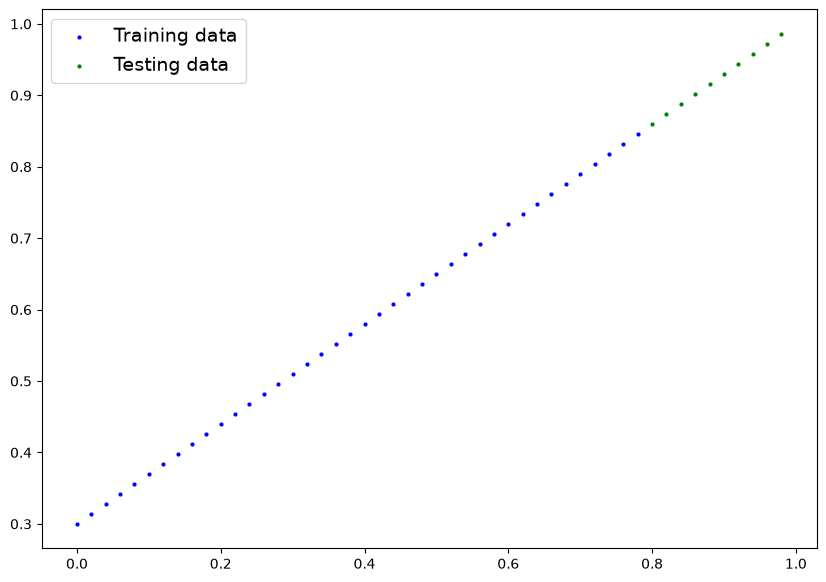

In [94]:
# plot data
plot_predictions(x_train,y_train,x_test,y_test)

### 6.2 Building a pytorch linear model

In [110]:
# create a linear regression model by subclassing nn.Module
class LinearRegressionModelv2(nn.Module):
    def __init__(self):
        super().__init__()
        #use nn.Linear() for creating a linear layer
        self.linear_layer=nn.Linear(in_features=1, out_features=1) # in_features is the number of input features and out_features is the number of output features
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.linear_layer(x) # the forward method defines how the model makes predictions

# set manual seed
torch.manual_seed(42)
model_1=LinearRegressionModel()
model_1, model_1.state_dict()        

(LinearRegressionModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [111]:
# check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [112]:
# set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### Training

we need:
* loss function
* optimizer
* Training loop
* Testing loop

In [113]:
#set up loss function and optimizer
loss_fn=nn.L1Loss() # mean absolute error
optimizer=torch.optim.SGD(params=model_1.parameters(), lr=0.01) # stochastic gradient descent optimizer with learning rate of 0.01


In [114]:
# traning loop
torch.manual_seed(42)
epochs=200

#Put data on target device
x_train=x_train.to(device)
y_train=y_train.to(device)
x_test=x_test.to(device)
y_test=y_test.to(device)

for epoch in range(epochs):
    model_1.train() # set the model to training mode
    y_pred=model_1(x_train) # make predictions
    loss=loss_fn(y_pred, y_train) # calculate the loss
    optimizer.zero_grad() # zero the gradients
    loss.backward() # backpropagate the loss
    optimizer.step() # update the parameters

## Testing loop
    
    model_1.eval() # set the model to evaluation mode
    with torch.inference_mode():
        test_pred=model_1(x_test) # make predictions on the test set
        test_loss=loss_fn(test_pred, y_test) # calculate the test loss

    if epoch%10==0:        
        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 0.5551779866218567 | Test Loss: 0.5739762187004089
Epoch: 10 | Loss: 0.439968079328537 | Test Loss: 0.4392664134502411
Epoch: 20 | Loss: 0.3247582018375397 | Test Loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954833924770355 | Test Loss: 0.16984669864177704
Epoch: 40 | Loss: 0.09433845430612564 | Test Loss: 0.03513690456748009
Epoch: 50 | Loss: 0.023886388167738914 | Test Loss: 0.04784907028079033
Epoch: 60 | Loss: 0.019956795498728752 | Test Loss: 0.045803118497133255
Epoch: 70 | Loss: 0.016517987474799156 | Test Loss: 0.037530567497015
Epoch: 80 | Loss: 0.013089174404740334 | Test Loss: 0.02994490973651409
Epoch: 90 | Loss: 0.009653178043663502 | Test Loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215683650225401 | Test Loss: 0.014086711220443249
Epoch: 110 | Loss: 0.00278724217787385 | Test Loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 130 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416

In [115]:
model_1.state_dict()


OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [116]:
weight, bias

(0.7, 0.3)

### 6.4 Making and evaluating predictions

In [117]:
#Turn model into evluation mode
model_1.eval()

#Make predictions with the model
with torch.inference_mode():
    y_preds=model_1(x_test)
y_preds    

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

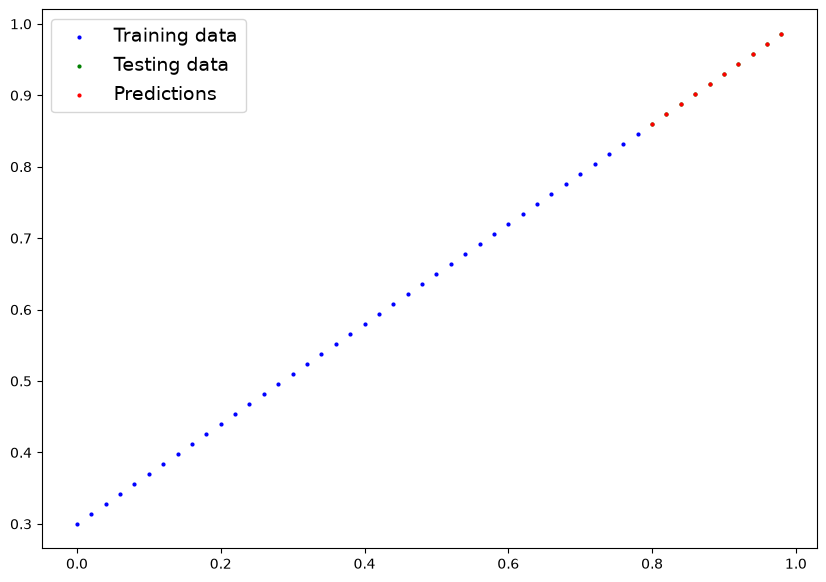

In [118]:
#checkout model prediction visually
plot_predictions(predictions=y_preds.cpu())


### 6.5 Saving and loading a trained model


In [119]:
from pathlib import Path   

#1. create model directory
model_path=Path("models")
model_path.mkdir(parents=True, exist_ok=True)

#2. create model save path
model_name="01_pytorch_workflow_model_1.pth"
model_save_path=model_path / model_name

#3. save the model state_dict
print(f"Saving model to: {model_save_path}")
torch.save(obj=model_1.state_dict(), f=model_save_path)

Saving model to: models\01_pytorch_workflow_model_1.pth


In [120]:
# loading a PyTorch model

#create a new instance of the model class
loaded_model_1=LinearRegressionModelv2()

#load the saved model_1 state dict
loaded_model_1.load_state_dict(torch.load(f=model_save_path))

#put the loaded model on the target device
loaded_model_1.to(device)

C:\Users\richi\AppData\Local\Temp\ipykernel_30060\219322605.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_1.load_state_dict(torch.load(f=model_save_path))

LinearRegressionModelv2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [121]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [122]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [ ]:
#evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_preds=loaded_model_1(x_test)
y_preds==loaded_model_preds    

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')